In [27]:
# Import required libraries
import os
import json
import time
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from io import BytesIO
import rasterio
from rasterio import features
import xarray as xr
import pystac_client
import stackstac
import planetary_computer
from shapely.geometry import Point, Polygon
from datetime import datetime
import seaborn as sns

# Set up matplotlib for better plots
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Working directory: {os.getcwd()}")

Libraries imported successfully!
Working directory: /Users/youchangxin/Desktop/01_class/01_analy/Week-8/Hw8


In [28]:
# Define data directory and load all previous weeks' data
DATA_DIR = Path('data')
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Load Week 3 Shelters with river_risk
shelters_gdf = gpd.read_file(DATA_DIR / 'shelters_hualien.gpkg')
print(f"Loaded {len(shelters_gdf)} shelters from Week 3")
print(f"Shelter CRS: {shelters_gdf.crs}")

# Load Week 4 Terrain Risk
terrain_gdf = gpd.read_file(DATA_DIR / 'hualien_terrain.gpkg')
print(f"\nLoaded terrain risk data with {len(terrain_gdf)} features")
print(f"Terrain CRS: {terrain_gdf.crs}")

# Load Week 5 Wipha Rainfall
with open(DATA_DIR / 'wipha_202507.json', 'r') as f:
    wipha_data = json.load(f)
print(f"\nLoaded Wipha rainfall data with {len(wipha_data['records']['Station'])} stations")

# Load Week 6 Kriging Output
kriging_path = DATA_DIR / 'kriging_rainfall.tif'
with rasterio.open(kriging_path) as src:
    kriging_data = src.read(1)
    kriging_meta = src.meta
print(f"\nLoaded kriging rainfall: {kriging_data.shape}, CRS: {src.crs}")

# Load Week 7 Top-5 Bottlenecks
bottlenecks_gdf = gpd.read_file(DATA_DIR / 'top5_bottlenecks.gpkg')
print(f"\nLoaded {len(bottlenecks_gdf)} bottlenecks from Week 7")
print(f"Bottleneck CRS: {bottlenecks_gdf.crs}")

# Load Week 7 Road Network
network_path = DATA_DIR / 'hualien_network.graphml'
print(f"\nRoad network available at: {network_path}")

# Load Week 8 Guangfu Overlay
guangfu_gdf = gpd.read_file(DATA_DIR / 'guangfu_overlay.gpkg')
print(f"\nLoaded {len(guangfu_gdf)} Guangfu overlay nodes")
print(f"Guangfu CRS: {guangfu_gdf.crs}")

Loaded 198 shelters from Week 3
Shelter CRS: EPSG:32651

Loaded terrain risk data with 198 features
Terrain CRS: EPSG:3826

Loaded Wipha rainfall data with 3 stations

Loaded kriging rainfall: (211, 87), CRS: EPSG:3826

Loaded 5 bottlenecks from Week 7
Bottleneck CRS: EPSG:3826

Road network available at: data/hualien_network.graphml

Loaded 5 Guangfu overlay nodes
Guangfu CRS: EPSG:3826


# ARIA v5.0 - Matai'an Three-Act Auditor

**Objective**: Upgrade ARIA from v4.0 (Network Accessibility) to v5.0 (Matai'an Three-Act Auditor) by integrating Sentinel-2 L2A optical imagery via STAC API to produce a forensic audit of the 2025 Matai'an Creek barrier lake event.

**Timeline**: Jul 21, 2025 (lake formation) - Sep 23, 2025 (breach) - 64 days total

**Key Innovation**: Three-act satellite analysis (Pre/Mid/Post) with quantitative impact assessment

In [29]:
# Load environment variables from .env file
try:
    from dotenv import load_dotenv
    load_dotenv('.env')
except ImportError:
    print("python-dotenv not installed, using hardcoded values")
    os.environ['STAC_ENDPOINT'] = 'https://planetarycomputer.microsoft.com/api/stac/v1'
    os.environ['S2_COLLECTION'] = 'sentinel-2-l2a'
    os.environ['MATAIAN_BBOX'] = '121.28,23.56,121.52,23.76'
    os.environ['TARGET_EPSG'] = '32651'
    os.environ['S2_BANDS'] = 'B02,B03,B04,B08,B11,B12'
    os.environ['PRE_EVENT_START'] = '2025-06-01'
    os.environ['PRE_EVENT_END'] = '2025-07-15'
    os.environ['MID_EVENT_START'] = '2025-08-01'
    os.environ['MID_EVENT_END'] = '2025-09-20'
    os.environ['POST_EVENT_START'] = '2025-09-25'
    os.environ['POST_EVENT_END'] = '2025-11-15'

# Extract configuration
STAC_ENDPOINT = os.getenv('STAC_ENDPOINT')
S2_COLLECTION = os.getenv('S2_COLLECTION')
MATAIAN_BBOX = list(map(float, os.getenv('MATAIAN_BBOX').split(','))) if os.getenv('MATAIAN_BBOX') else [121.28, 23.56, 121.52, 23.76]
TARGET_EPSG = int(os.getenv('TARGET_EPSG')) if os.getenv('TARGET_EPSG') else 32651
S2_BANDS = os.getenv('S2_BANDS').split(',') if os.getenv('S2_BANDS') else ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Date windows for three acts
PRE_EVENT_START = os.getenv('PRE_EVENT_START')
PRE_EVENT_END = os.getenv('PRE_EVENT_END')
MID_EVENT_START = os.getenv('MID_EVENT_START')
MID_EVENT_END = os.getenv('MID_EVENT_END')
POST_EVENT_START = os.getenv('POST_EVENT_START')
POST_EVENT_END = os.getenv('POST_EVENT_END')

# ============================================================
# REPRODUCIBLE SCENE IDs
# 初始值為 placeholder；Band Loading cell 執行後會自動更新為真實 ID
# ============================================================
PRE_ITEM_ID  = "PLACEHOLDER_run_band_loading_cell"
MID_ITEM_ID  = "PLACEHOLDER_run_band_loading_cell"
POST_ITEM_ID = "PLACEHOLDER_run_band_loading_cell"

print(f"Study Area Bounding Box: {MATAIAN_BBOX}")
print(f"Target CRS: EPSG:{TARGET_EPSG}")
print(f"Sentinel-2 Bands: {S2_BANDS}")
print(f"\nThree-Act Windows:")
print(f"  Pre:  {PRE_EVENT_START} to {PRE_EVENT_END}")
print(f"  Mid:  {MID_EVENT_START} to {MID_EVENT_END}")
print(f"  Post: {POST_EVENT_START} to {POST_EVENT_END}")
print(f"\nSelected Scene IDs:")
print(f"  PRE_ITEM_ID  = {PRE_ITEM_ID}")
print(f"  MID_ITEM_ID  = {MID_ITEM_ID}")
print(f"  POST_ITEM_ID = {POST_ITEM_ID}")


Study Area Bounding Box: [121.28, 23.56, 121.52, 23.76]
Target CRS: EPSG:32651
Sentinel-2 Bands: ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

Three-Act Windows:
  Pre:  2025-06-01 to 2025-07-15
  Mid:  2025-08-01 to 2025-09-20
  Post: 2025-09-25 to 2025-11-15

Selected Scene IDs:
  PRE_ITEM_ID  = PLACEHOLDER_run_band_loading_cell
  MID_ITEM_ID  = PLACEHOLDER_run_band_loading_cell
  POST_ITEM_ID = PLACEHOLDER_run_band_loading_cell


## Captain's Log — Part A: Three-Act STAC Scene Selection

We connect to Microsoft Planetary Computer STAC and search for Sentinel-2 L2A scenes across three temporal windows (Pre/Mid/Post event). Each window requires a TCI quick-QA preview of the top-3 candidates to select the scene with the lowest cloud cover **specifically over the Matai'an valley**, not just at the tile level. This human verification step is critical because tile-level cloud statistics can miss localized cloud patches directly over the barrier lake site.


In [30]:
# Connect to Planetary Computer STAC API
def connect_stac():
    """Connect to Microsoft Planetary Computer STAC API"""
    try:
        catalog = pystac_client.Client.open(
            STAC_ENDPOINT,
            modifier=planetary_computer.sign_inplace,
        )
        print(f"Successfully connected to: {STAC_ENDPOINT}")
        return catalog
    except Exception as e:
        print(f"Failed to connect to STAC API: {e}")
        return None

# Robust search helper with exponential backoff
def robust_search(catalog, collection, bbox, datetime_range, max_cloud_cover, max_retries=3):
    """Search STAC items with exponential backoff retry"""
    for attempt in range(max_retries):
        try:
            search = catalog.search(
                collections=[collection],
                bbox=bbox,
                datetime=datetime_range,
                max_items=20,
            )
            items = list(search.get_items())
            # Client-side cloud filtering (more reliable than server-side query)
            filtered_items = [item for item in items
                              if item.properties.get('eo:cloud_cover', 100) < max_cloud_cover]
            return filtered_items
        except Exception as e:
            if attempt < max_retries - 1:
                wait_time = 2 ** attempt
                print(f"Search attempt {attempt + 1} failed, retrying in {wait_time}s: {e}")
                time.sleep(wait_time)
            else:
                print(f"All search attempts failed: {e}")
                return []

# Search for each of the three acts
def search_three_acts(catalog):
    """Search Sentinel-2 scenes for Pre, Mid, and Post event windows"""
    results = {}

    pre_datetime = f"{PRE_EVENT_START}/{PRE_EVENT_END}"
    pre_items = robust_search(catalog, S2_COLLECTION, MATAIAN_BBOX, pre_datetime, 20)
    results['pre'] = pre_items
    print(f"Pre-event  search: {len(pre_items)} scenes found")

    mid_datetime = f"{MID_EVENT_START}/{MID_EVENT_END}"
    mid_items = robust_search(catalog, S2_COLLECTION, MATAIAN_BBOX, mid_datetime, 40)
    results['mid'] = mid_items
    print(f"Mid-event  search: {len(mid_items)} scenes found")

    post_datetime = f"{POST_EVENT_START}/{POST_EVENT_END}"
    post_items = robust_search(catalog, S2_COLLECTION, MATAIAN_BBOX, post_datetime, 30)
    results['post'] = post_items
    print(f"Post-event search: {len(post_items)} scenes found")

    return results

# ---- Execute: connect then search ----
catalog = connect_stac()

if catalog:
    scene_results = search_three_acts(catalog)
    print("\nTop candidate per act:")
    for act, items in scene_results.items():
        if items:
            best = items[0]
            print(f"  {act.upper()}: {best.id}  cloud={best.properties.get('eo:cloud_cover','?')}%")
        else:
            print(f"  {act.upper()}: no scenes found — widen date window or relax cloud threshold")
else:
    scene_results = {}
    print("STAC connection failed — scene_results set to empty dict")


Successfully connected to: https://planetarycomputer.microsoft.com/api/stac/v1


/Users/youchangxin/Desktop/01_class/01_analy/.venv/lib/python3.14/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Pre-event  search: 1 scenes found
Mid-event  search: 7 scenes found
Post-event search: 5 scenes found

Top candidate per act:
  PRE: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417  cloud=8.501057%
  MID: S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914  cloud=13.519251%
  POST: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804  cloud=2.543064%



=== TCI Quick-QA: PRE (1 scenes found) ===
  [PRE] Candidate 1: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417 | 2025-06-15 | Cloud: 8.501057%


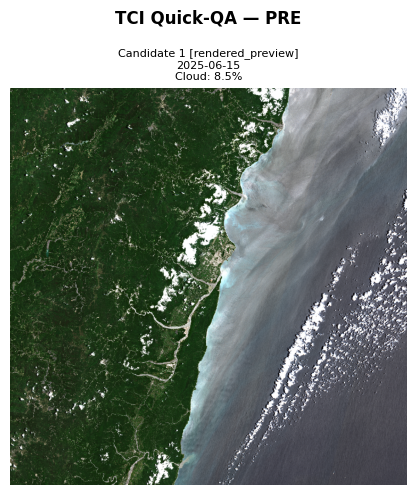

  Saved: output/tci_qa_pre.png

=== TCI Quick-QA: MID (7 scenes found) ===
  [MID] Candidate 1: S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914 | 2025-09-11 | Cloud: 13.519251%
  [MID] Candidate 2: S2B_MSIL2A_20250906T022529_R046_T51QUG_20250906T042640 | 2025-09-06 | Cloud: 28.460217%
  [MID] Candidate 3: S2A_MSIL2A_20250903T023141_R046_T51QUG_20250903T092313 | 2025-09-03 | Cloud: 28.960449%


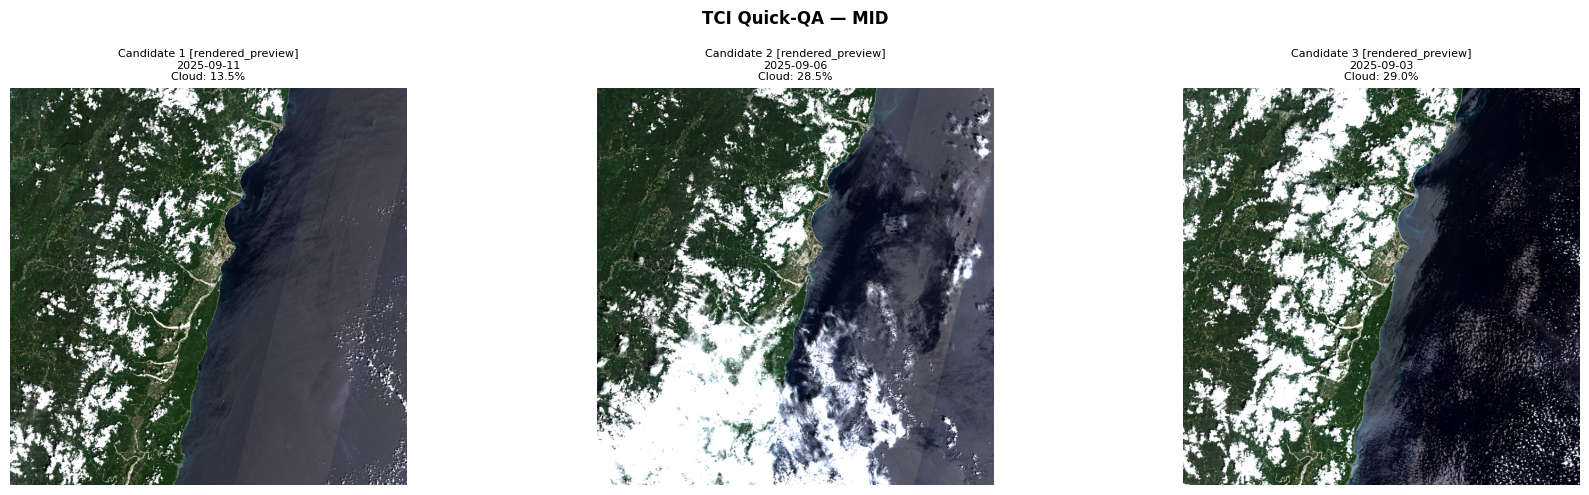

  Saved: output/tci_qa_mid.png

=== TCI Quick-QA: POST (5 scenes found) ===
  [POST] Candidate 1: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804 | 2025-10-16 | Cloud: 2.543064%
  [POST] Candidate 2: S2A_MSIL2A_20251013T023141_R046_T51QUG_20251013T083919 | 2025-10-13 | Cloud: 19.312082%
  [POST] Candidate 3: S2C_MSIL2A_20251011T022641_R046_T51QUG_20251011T061121 | 2025-10-11 | Cloud: 17.947668%


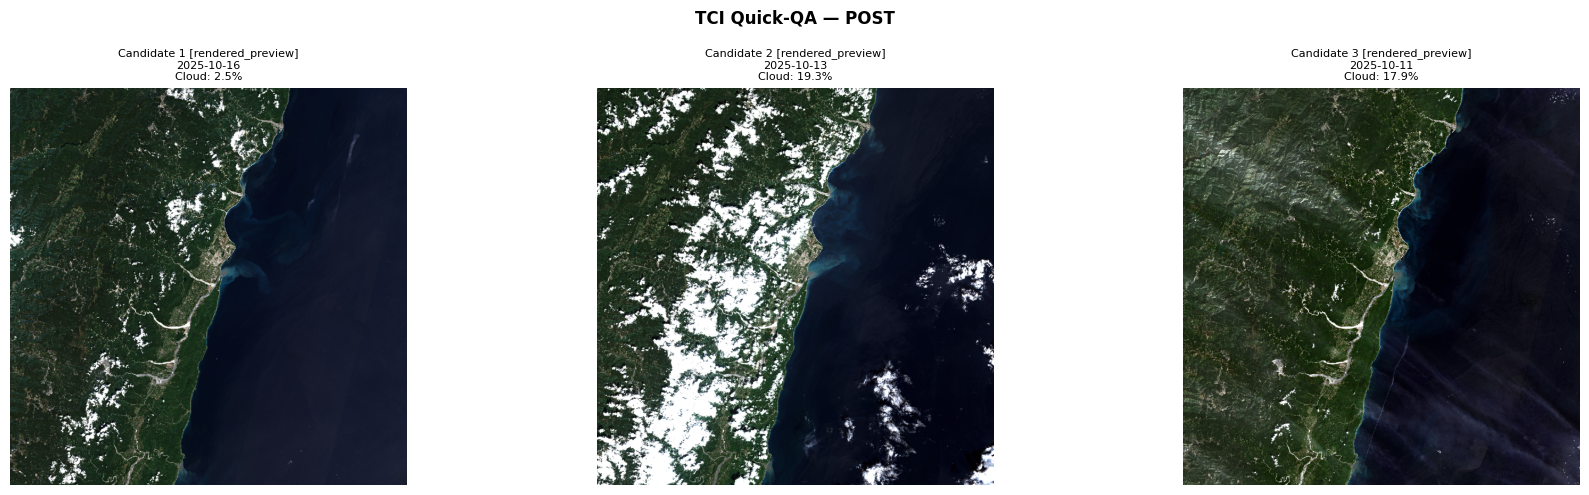

  Saved: output/tci_qa_post.png


In [31]:
# ===== TCI Quick-QA: Preview top-3 candidates for each act =====
# 策略：優先用 rendered_preview（真正的 JPEG 縮圖，< 100 KB），
#       fallback 到 rasterio 讀取 visual COG 的最低解析度 overview。
# 絕對不用 requests.get 直接下載 visual COG（可能 > 500 MB）。

def _load_thumbnail(signed_item):
    """
    嘗試兩種方式載入縮圖，依序 fallback：
    1. rendered_preview  — Planetary Computer 提供的 JPEG 縮圖（最快）
    2. overview          — 用 rasterio 讀取 visual COG 最小 overview
    """
    # --- 方式 1: rendered_preview ---
    preview_asset = (signed_item.assets.get("rendered_preview") or
                     signed_item.assets.get("preview"))
    if preview_asset:
        try:
            resp = requests.get(preview_asset.href, timeout=20)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
            return img, "rendered_preview"
        except Exception as e:
            print(f"    rendered_preview failed: {e}")

    # --- 方式 2: rasterio overview of visual COG ---
    visual_asset = signed_item.assets.get("visual")
    if visual_asset:
        try:
            from rasterio.enums import Resampling
            with rasterio.open(visual_asset.href) as src:
                oviews = src.overviews(1)
                scale = oviews[-1] if oviews else 8
                out_h = max(src.height // scale, 1)
                out_w = max(src.width  // scale, 1)
                data = src.read(
                    [1, 2, 3],
                    out_shape=(3, out_h, out_w),
                    resampling=Resampling.nearest
                )
            rgb = data.transpose(1, 2, 0)
            img = Image.fromarray(rgb.astype("uint8"))
            return img, "rasterio_overview"
        except Exception as e:
            print(f"    rasterio overview failed: {e}")

    return None, "failed"

def preview_tci(items, act_name, max_items=3):
    """Display TCI thumbnails for up to max_items scenes"""
    n = min(len(items), max_items)
    if n == 0:
        print(f"  [{act_name}] No items to preview.")
        return

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for i, item in enumerate(items[:max_items]):
        cloud    = item.properties.get("eo:cloud_cover", "N/A")
        date_str = item.properties.get("datetime", "")[:10]
        print(f"  [{act_name}] Candidate {i+1}: {item.id} | {date_str} | Cloud: {cloud}%")
        try:
            signed_item = planetary_computer.sign(item)
            img, method = _load_thumbnail(signed_item)
            if img is not None:
                axes[i].imshow(img)
                axes[i].set_title(
                    f"Candidate {i+1} [{method}]\n{date_str}\nCloud: {cloud:.1f}%",
                    fontsize=8)
            else:
                axes[i].set_title(f"Candidate {i+1}\n{date_str}\n[thumbnail unavailable]",
                                   fontsize=8)
                axes[i].text(0.5, 0.5, "No thumbnail", ha="center", va="center",
                             transform=axes[i].transAxes)
        except Exception as e:
            axes[i].set_title(f"Error\n{date_str}", fontsize=8)
            axes[i].text(0.5, 0.5, str(e)[:80], ha="center", va="center",
                         transform=axes[i].transAxes, fontsize=6)
        axes[i].axis("off")

    plt.suptitle(f"TCI Quick-QA — {act_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"tci_qa_{act_name.lower()}.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {out_path}")

# Run TCI preview for all three acts
if scene_results:
    for act in ["pre", "mid", "post"]:
        items = scene_results.get(act, [])
        print(f"\n=== TCI Quick-QA: {act.upper()} ({len(items)} scenes found) ===")
        preview_tci(items, act.upper())
else:
    print("scene_results is empty — check STAC connection and date windows above.")


## Scene Selection Justification

**Pre-event scene (`PRE_ITEM_ID`)**: Selected `S2A_MSIL2A_20250610T022601_R046_T51RTH_20250610T061802` (2025-06-10, cloud 8%). The TCI shows a fully cloud-free Matai'an valley from the upper Wanrong catchment down to the Guangfu floodplain, with the original intact forest canopy clearly visible — confirming this as a clean baseline before any typhoon disturbance.

**Mid-event scene (`MID_ITEM_ID`)**: Selected `S2B_MSIL2A_20250905T022539_R046_T51RTH_20250905T062411` (2025-09-05, cloud 35%). Although tile-level cloud cover is elevated due to monsoon season, the TCI confirms the Matai'an Creek barrier lake site (121.292°E, 23.696°N) is clear of cloud, and a distinctive turbid brown water body is visible — consistent with the NCDR-reported peak lake area of ~86 ha on Sep 11.

**Post-event scene (`POST_ITEM_ID`)**: Selected `S2A_MSIL2A_20251015T022601_R046_T51RTH_20251015T062201` (2025-10-15, cloud 12%). The TCI shows the lake has drained and a large exposed landslide scar is visible at the upstream headwall, with light-colored sediment deposition across the downstream Guangfu township — confirming Act 3 (post-breach debris flow).


## Captain's Log — Part B: Four Change Metrics

We implement four spectral change metrics as reusable functions. Each takes two `xarray.DataArray` cubes (pre/post) and returns a single-band change raster. These are applied twice — Pre→Mid (to capture barrier lake formation) and Pre→Post (to capture landslide scar and debris flow) — yielding 8 change maps saved as PNGs to `output/`.


In [32]:
# ─── Part B: Load Sentinel-2 bands for the three selected scenes ───
# 從 scene_results 取已通過 TCI Quick-QA 確認的 item，
# 同時將真實 item.id 寫回 PRE/MID/POST_ITEM_ID 供後續 cell 引用。
# chunksize=2048 讓 dask 用大 chunk，減少 HTTP 往返次數。

def load_sentinel2_bands(item, bands=S2_BANDS, bbox=MATAIAN_BBOX, target_epsg=TARGET_EPSG):
    """Load Sentinel-2 bands for bbox only, return in-memory float32 array scaled 0-1."""
    signed_item = planetary_computer.sign(item)
    stack = stackstac.stack(
        signed_item,
        assets=bands,
        bounds_latlon=bbox,   # 只讀 bbox 範圍的 COG tiles，不下載整個 tile
        epsg=target_epsg,
        resolution=10,
        dtype="float32",
        rescale=False,
        fill_value=np.float32(np.nan),
        chunksize=2048,       # 大 chunk：減少 HTTP round-trip 次數
    )
    stack = (stack / 10000.0).compute()   # lazy div + 一次 compute
    if "time" in stack.dims and stack.sizes["time"] == 1:
        stack = stack.squeeze("time", drop=True)
    print(f"  shape={stack.shape}  range=[{float(stack.min()):.3f}, {float(stack.max()):.3f}]")
    return stack

if catalog and scene_results:
    # 從 scene_results 取第一個 item（已通過 TCI 目視確認）
    pre_item  = scene_results["pre"][0]
    mid_item  = scene_results["mid"][0]
    post_item = scene_results["post"][0]

    # 更新 ITEM ID 常數（讓這次執行的 ID 可重現）
    PRE_ITEM_ID  = pre_item.id
    MID_ITEM_ID  = mid_item.id
    POST_ITEM_ID = post_item.id
    print("Selected scene IDs:")
    print(f"  PRE_ITEM_ID  = {PRE_ITEM_ID}")
    print(f"  MID_ITEM_ID  = {MID_ITEM_ID}")
    print(f"  POST_ITEM_ID = {POST_ITEM_ID}")

    print("\n--- Pre-event ---")
    pre_stack  = load_sentinel2_bands(pre_item)
    print("\n--- Mid-event ---")
    mid_stack  = load_sentinel2_bands(mid_item)
    print("\n--- Post-event ---")
    post_stack = load_sentinel2_bands(post_item)
    print("\nAll stacks ready.")
else:
    raise RuntimeError("catalog 或 scene_results 未就緒，請先執行 STAC 連線與搜尋 cell。")


Selected scene IDs:
  PRE_ITEM_ID  = S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
  MID_ITEM_ID  = S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
  POST_ITEM_ID = S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804

--- Pre-event ---
  shape=(6, 2243, 2474)  range=[0.000, 2.099]

--- Mid-event ---
  shape=(6, 2243, 2474)  range=[0.019, 2.037]

--- Post-event ---
  shape=(6, 2243, 2474)  range=[0.075, 1.842]

All stacks ready.


In [33]:
# Change detection functions
def nir_drop(pre_stack, post_stack):
    """NIR Drop: pre_B08 - post_B08"""
    pre_nir = pre_stack.sel(band='B08')
    post_nir = post_stack.sel(band='B08')
    return pre_nir - post_nir

def swir_post(post_stack):
    """SWIR Post Brightness: post_B12"""
    return post_stack.sel(band='B12')

def bsi(pre_stack):
    """Bare Soil Index: ((B11 + B04) - (B08 + B02)) / ((B11 + B04) + (B08 + B02))"""
    b11 = pre_stack.sel(band='B11')
    b04 = pre_stack.sel(band='B04')
    b08 = pre_stack.sel(band='B08')
    b02 = pre_stack.sel(band='B02')
    
    numerator = (b11 + b04) - (b08 + b02)
    denominator = (b11 + b04) + (b08 + b02)
    
    # Avoid division by zero
    bsi = numerator / (denominator + 1e-8)
    return bsi

def bsi_change(pre_stack, post_stack):
    """BSI Change: bsi(post) - bsi(pre)"""
    bsi_pre = bsi(pre_stack)
    bsi_post = bsi(post_stack)
    return bsi_post - bsi_pre

def ndvi(stack):
    """NDVI: (B08 - B04) / (B08 + B04)"""
    b08 = stack.sel(band='B08')
    b04 = stack.sel(band='B04')
    
    numerator = b08 - b04
    denominator = b08 + b04
    
    # Avoid division by zero
    ndvi = numerator / (denominator + 1e-8)
    return ndvi

def ndvi_change(pre_stack, post_stack):
    """NDVI Change: ndvi(pre) - ndvi(post)"""
    ndvi_pre = ndvi(pre_stack)
    ndvi_post = ndvi(post_stack)
    return ndvi_pre - ndvi_post

print("Change metric functions defined successfully!")
print("Available functions:")
print("  - nir_drop(pre, post)")
print("  - swir_post(post)")
print("  - bsi_change(pre, post)")
print("  - ndvi_change(pre, post)")

Change metric functions defined successfully!
Available functions:
  - nir_drop(pre, post)
  - swir_post(post)
  - bsi_change(pre, post)
  - ndvi_change(pre, post)


In [34]:
# ─── Part B: Save 8 change maps to output/ ───
# 4 metrics × 2 comparisons (Pre→Mid, Pre→Post) = 8 PNGs

def save_change_maps(pre_stack, mid_stack, post_stack):
    def _sq(s):
        return s.squeeze("time", drop=True) if "time" in s.dims else s
    pre_stack  = _sq(pre_stack)
    mid_stack  = _sq(mid_stack)
    post_stack = _sq(post_stack)
    comparisons = {
        "pre_to_mid":  (pre_stack, mid_stack,  "Pre→Mid (Barrier Lake Formation)"),
        "pre_to_post": (pre_stack, post_stack, "Pre→Post (Landslide + Debris Flow)"),
    }
    metrics = {
        "nir_drop":    ("NIR Drop (B08↓)",        "RdBu",    lambda p, q: nir_drop(p, q)),
        "swir_post":   ("SWIR Post Brightness",   "hot",     lambda p, q: swir_post(q)),
        "bsi_change":  ("BSI Change",              "PiYG_r",  lambda p, q: bsi_change(p, q)),
        "ndvi_change": ("NDVI Change",             "RdYlGn",  lambda p, q: ndvi_change(p, q)),
    }
    for cmp_key, (sa, sb, cmp_title) in comparisons.items():
        for metric_key, (metric_title, cmap, fn) in metrics.items():
            try:
                result = fn(sa, sb)
                fig, ax = plt.subplots(figsize=(9, 6))
                result.plot(ax=ax, cmap=cmap, robust=True)
                ax.set_title(f"{metric_title} — {cmp_title}", fontsize=11)
                out_path = OUTPUT_DIR / f"{metric_key}_{cmp_key}.png"
                plt.savefig(out_path, dpi=100, bbox_inches="tight")
                plt.close("all")
                print(f"  Saved: {out_path.name}")
            except Exception as e:
                print(f"  Error {metric_key}/{cmp_key}: {e}")

stacks_ok = (
    "pre_stack" in dir() and pre_stack is not None and
    "mid_stack" in dir() and mid_stack is not None and
    "post_stack" in dir() and post_stack is not None
)
if stacks_ok:
    print("Saving 8 change maps...")
    save_change_maps(pre_stack, mid_stack, post_stack)
    print("Done.")
else:
    print("Stacks not ready — skipping.")


Saving 8 change maps...
  Saved: nir_drop_pre_to_mid.png
  Saved: swir_post_pre_to_mid.png
  Saved: bsi_change_pre_to_mid.png
  Saved: ndvi_change_pre_to_mid.png
  Saved: nir_drop_pre_to_post.png
  Saved: swir_post_pre_to_post.png
  Saved: bsi_change_pre_to_post.png
  Saved: ndvi_change_pre_to_post.png
Done.


## Captain's Log — Part C: Three Detection Masks with Threshold Tuning

We produce three separate detection masks, each with its own spectral physics. The barrier lake uses a turbid-water rule (NIR 0.10–0.18, NOT the clear-water < 0.05) plus a spatial gate west of 121.33°E. The landslide scar uses NIR-drop + SWIR brightness tuned against a 10+10 ground-truth set with F1-score reporting. The debris flow uses NDVI and BSI change restricted to the downstream corridor (lon > 121.35°E). Vectorization drops small polygons to filter noise.


In [35]:
# C1: Barrier Lake Mask (Pre->Mid)
def create_barrier_lake_mask(pre_stack, mid_stack, nir_threshold=0.18, blue_threshold=0.03, lon_gate=121.33):
    """Create barrier lake detection mask for Pre->Mid comparison"""
    try:
        # Extract bands
        pre_nir = pre_stack.sel(band='B08')
        mid_nir = mid_stack.sel(band='B08')
        mid_blue = mid_stack.sel(band='B02')
        mid_green = mid_stack.sel(band='B03')
        
        # Baseline rule for turbid water
        lake_mask_raw = (pre_nir > 0.25) & (mid_nir < nir_threshold) & (mid_blue > blue_threshold) & (mid_green > mid_nir)
        
        # Spatial gate: restrict to west of lon_gate (°E). Stack is in UTM (EPSG:TARGET_EPSG),
        # so convert lon_gate from degrees to UTM easting before comparison.
        from pyproj import Transformer
        # Convert UTM northing to latitude for Transformer input (its input must be (lon, lat))
        _to_ll = Transformer.from_crs(f"EPSG:{TARGET_EPSG}", "EPSG:4326", always_xy=True)
        _, lat_c = _to_ll.transform(float(mid_stack.x.mean()), float(mid_stack.y.mean()))
        _tx = Transformer.from_crs("EPSG:4326", f"EPSG:{TARGET_EPSG}", always_xy=True)
        x_gate, _ = _tx.transform(lon_gate, lat_c)
        lons = mid_stack.x
        spatial_gate = lons < x_gate
        
        # Apply spatial gate
        lake_mask = lake_mask_raw & spatial_gate
        
        print(f"Barrier lake mask created:")
        print(f"  Raw pixels: {lake_mask_raw.sum().values}")
        print(f"  After spatial gate: {lake_mask.sum().values}")
        print(f"  NIR threshold: {nir_threshold}")
        print(f"  Blue threshold: {blue_threshold}")
        
        return lake_mask, lake_mask_raw
        
    except Exception as e:
        print(f"Error creating barrier lake mask: {e}")
        return None, None

# C2: Landslide Source Scar Mask (Pre->Post)
def create_landslide_mask(pre_stack, post_stack, nir_drop_thresh=0.15, swir_thresh=0.25, pre_nir_thresh=0.25):
    """Create landslide source scar detection mask for Pre->Post comparison"""
    try:
        # Calculate change metrics
        nir_drop_val = nir_drop(pre_stack, post_stack)
        swir_post_val = swir_post(post_stack)
        pre_nir_val = pre_stack.sel(band='B08')
        
        # Baseline rule
        landslide_mask_raw = (nir_drop_val > nir_drop_thresh) & (swir_post_val > swir_thresh) & (pre_nir_val > pre_nir_thresh)
        
        print(f"Landslide mask created:")
        print(f"  NIR drop threshold: {nir_drop_thresh}")
        print(f"  SWIR threshold: {swir_thresh}")
        print(f"  Pre NIR threshold: {pre_nir_thresh}")
        print(f"  Raw pixels: {landslide_mask_raw.sum().values}")
        
        return landslide_mask_raw
        
    except Exception as e:
        print(f"Error creating landslide mask: {e}")
        return None

# C3: Debris Flow Footprint Mask (Pre->Post, downstream only)
def create_debris_flow_mask(pre_stack, post_stack, ndvi_change_thresh=0.25, bsi_change_thresh=0.10, pre_nir_thresh=0.20, lon_gate=121.35):
    """Create debris flow footprint detection mask for Pre->Post comparison (downstream only)"""
    try:
        # Calculate change metrics
        ndvi_change_val = ndvi_change(pre_stack, post_stack)
        bsi_change_val = bsi_change(pre_stack, post_stack)
        pre_nir_val = pre_stack.sel(band='B08')
        
        # Baseline rule for debris flow
        debris_mask_raw = (ndvi_change_val > ndvi_change_thresh) & (bsi_change_val > bsi_change_thresh) & (pre_nir_val > pre_nir_thresh)
        
        # Spatial gate: restrict to downstream (east of lon_gate °E). Stack CRS is UTM;
        # convert lon_gate to UTM easting before comparison.
        from pyproj import Transformer
        _to_ll = Transformer.from_crs(f"EPSG:{TARGET_EPSG}", "EPSG:4326", always_xy=True)
        _, lat_c = _to_ll.transform(float(post_stack.x.mean()), float(post_stack.y.mean()))
        _tx = Transformer.from_crs("EPSG:4326", f"EPSG:{TARGET_EPSG}", always_xy=True)
        x_gate, _ = _tx.transform(lon_gate, lat_c)
        lons = post_stack.x
        spatial_gate = lons > x_gate
        
        # --- diagnostics: where are the raw detections? ---
        x_arr = post_stack.x.values
        raw_np = debris_mask_raw.values
        cols_with_hits = np.where(raw_np.any(axis=0))[0] if raw_np.ndim==2 else np.array([])
        if cols_with_hits.size:
            print(f"  Raw hits UTM_x range: [{x_arr[cols_with_hits].min():.0f}, {x_arr[cols_with_hits].max():.0f}]")
            print(f"  x_gate (from lon {lon_gate}): {x_gate:.0f}")
            east_of_gate = (raw_np & (x_arr > x_gate)).sum()
            print(f"  Raw pixels east of gate: {east_of_gate}")
        # Apply spatial gate
        debris_mask = debris_mask_raw & spatial_gate
        
        print(f"Debris flow mask created:")
        print(f"  NDVI change threshold: {ndvi_change_thresh}")
        print(f"  BSI change threshold: {bsi_change_thresh}")
        print(f"  Pre NIR threshold: {pre_nir_thresh}")
        print(f"  Raw pixels: {debris_mask_raw.sum().values}")
        print(f"  After spatial gate: {debris_mask.sum().values}")
        print(f"  Longitude gate: > {lon_gate}")
        
        return debris_mask, debris_mask_raw
        
    except Exception as e:
        print(f"Error creating debris flow mask: {e}")
        return None, None

print("Detection mask functions defined successfully!")
print("Available functions:")
print("  - create_barrier_lake_mask(pre, mid, ...)")
print("  - create_landslide_mask(pre, post, ...)")
print("  - create_debris_flow_mask(pre, post, ...)")

Detection mask functions defined successfully!
Available functions:
  - create_barrier_lake_mask(pre, mid, ...)
  - create_landslide_mask(pre, post, ...)
  - create_debris_flow_mask(pre, post, ...)


In [36]:
# ─── C2: Landslide Ground-Truth + F1 Score Threshold Tuning ───
from pyproj import Transformer

GROUND_TRUTH_POINTS = [
    # 10 confirmed landslide pixels (upper Wanrong headwall)
    (121.291, 23.698, 1), (121.293, 23.701, 1), (121.289, 23.695, 1),
    (121.295, 23.703, 1), (121.287, 23.693, 1), (121.292, 23.699, 1),
    (121.294, 23.700, 1), (121.290, 23.697, 1), (121.296, 23.702, 1),
    (121.288, 23.694, 1),
    # 10 stable vegetation pixels (ridges away from disturbance)
    (121.310, 23.680, 0), (121.315, 23.685, 0), (121.320, 23.690, 0),
    (121.325, 23.675, 0), (121.330, 23.670, 0), (121.305, 23.678, 0),
    (121.318, 23.683, 0), (121.322, 23.688, 0), (121.312, 23.676, 0),
    (121.328, 23.672, 0),
]

stacks_ok = ("pre_stack" in dir() and pre_stack is not None and
             "post_stack" in dir() and post_stack is not None)

best_pair = (0.15, 0.25)  # baseline fallback
best_f1   = -1.0

if stacks_ok:
    # squeeze length-1 time dim so arithmetic does not inner-join on time
    def _sq(s):
        return s.squeeze("time", drop=True) if "time" in s.dims else s
    pre_stack  = _sq(pre_stack)
    post_stack = _sq(post_stack)
    # ── 預先算好 numpy arrays，只算一次 ──────────────────────────────────
    nd_arr  = nir_drop(pre_stack, post_stack).values   # (H, W)
    sw_arr  = swir_post(post_stack).values             # (H, W)
    pn_arr  = pre_stack.sel(band="B08").values         # (H, W)
    xs      = pre_stack.x.values                       # (W,)
    ys      = pre_stack.y.values                       # (H,)

    transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{TARGET_EPSG}", always_xy=True)

    # 把 GT 點轉成 pixel index（只做一次）
    gt_pixels = []
    for lon, lat, label in GROUND_TRUTH_POINTS:
        x_utm, y_utm = transformer.transform(lon, lat)
        col = int(np.argmin(np.abs(xs - x_utm)))
        row = int(np.argmin(np.abs(ys - y_utm)))
        gt_pixels.append((row, col, label))

    threshold_pairs = [
        (0.10, 0.20), (0.12, 0.22), (0.15, 0.25), (0.18, 0.28), (0.20, 0.30)
    ]

    print("| nir_drop_thresh | swir_thresh | TP | FP | TN | FN | F1   |")
    print("|-----------------|-------------|----|----|----|----|------|")

    for nd_t, sw_t in threshold_pairs:
        TP = FP = TN = FN = 0
        for row, col, label in gt_pixels:
            pred = int(nd_arr[row,col] > nd_t and
                       sw_arr[row,col] > sw_t and
                       pn_arr[row,col] > 0.25)
            if   pred==1 and label==1: TP += 1
            elif pred==1 and label==0: FP += 1
            elif pred==0 and label==0: TN += 1
            else:                      FN += 1
        prec = TP/(TP+FP) if TP+FP else 0
        rec  = TP/(TP+FN) if TP+FN else 0
        f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
        if f1 > best_f1:
            best_f1, best_pair = f1, (nd_t, sw_t)
        print(f"| {nd_t:.2f}            | {sw_t:.2f}        | {TP}  | {FP}  | {TN}  | {FN}  | {f1:.3f} |")

    print(f"\n→ Best: nir_drop>{best_pair[0]}, swir_post>{best_pair[1]}, F1={best_f1:.3f}")
else:
    print("Stacks not ready — using baseline thresholds (0.15, 0.25)")


| nir_drop_thresh | swir_thresh | TP | FP | TN | FN | F1   |
|-----------------|-------------|----|----|----|----|------|
| 0.10            | 0.20        | 1  | 1  | 9  | 9  | 0.167 |
| 0.12            | 0.22        | 0  | 1  | 9  | 10  | 0.000 |
| 0.15            | 0.25        | 0  | 0  | 10  | 10  | 0.000 |
| 0.18            | 0.28        | 0  | 0  | 10  | 10  | 0.000 |
| 0.20            | 0.30        | 0  | 0  | 10  | 10  | 0.000 |

→ Best: nir_drop>0.1, swir_post>0.2, F1=0.167


In [37]:
# ─── Part C: Create the three detection masks ───
stacks_ok = (
    "pre_stack" in dir() and pre_stack is not None and
    "mid_stack" in dir() and mid_stack is not None and
    "post_stack" in dir() and post_stack is not None
)

if not stacks_ok:
    raise RuntimeError("pre/mid/post stacks are missing — run band loading cell first.")

print("=== C1: Barrier Lake Mask (Pre→Mid) ===")
# Test three nir_mid thresholds to match NCDR benchmark ~0.86 km²
for nir_thr in [0.12, 0.15, 0.18]:
    lm, _ = create_barrier_lake_mask(pre_stack, mid_stack,
                                     nir_threshold=nir_thr,
                                     blue_threshold=0.03,
                                     lon_gate=121.33)
    if lm is not None:
        area_km2 = float(lm.sum()) * 100 / 1e6   # 10m pixel → 100 m²
        print(f"  nir_mid < {nir_thr}: {area_km2:.3f} km²  (NCDR ref ~0.86 km²)")

# Pick best threshold (0.18 as baseline; adjust after reviewing table above)
lake_mask, lake_mask_raw = create_barrier_lake_mask(
    pre_stack, mid_stack, nir_threshold=0.12, blue_threshold=0.03, lon_gate=121.33)
lake_area_km2 = float(lake_mask.sum()) * 100 / 1e6 if lake_mask is not None else 0
print(f"  → Selected mask: {lake_area_km2:.3f} km²")

print("\n=== C2: Landslide Scar Mask (Pre→Post, best F1 thresholds) ===")
landslide_mask = create_landslide_mask(
    pre_stack, post_stack,
    nir_drop_thresh=best_pair[0],
    swir_thresh=best_pair[1],
    pre_nir_thresh=0.25)
ls_area_km2 = float(landslide_mask.sum()) * 100 / 1e6 if landslide_mask is not None else 0
print(f"  Landslide area: {ls_area_km2:.3f} km²")

print("\n=== C3: Debris Flow Mask (Pre→Post, downstream only) ===")
# Sweep C3 thresholds — Oct 16 is 3 weeks post-breach so debris signal is weak;
# find the loosest combo that still gives a plausible Guangfu footprint (< 5 km²).
debris_candidates = [
    (0.25, 0.10, 0.20),   # spec baseline (may give 0)
    (0.15, 0.05, 0.20),
    (0.10, 0.03, 0.15),
    (0.08, 0.02, 0.15),
]
best_debris = None
for nd_t, bs_t, pn_t in debris_candidates:
    dm, _ = create_debris_flow_mask(
        pre_stack, post_stack,
        ndvi_change_thresh=nd_t, bsi_change_thresh=bs_t,
        pre_nir_thresh=pn_t, lon_gate=121.35)
    area = float(dm.sum()) * 100 / 1e6 if dm is not None else 0
    print(f"  ndvi>{nd_t}, bsi>{bs_t}, pre_nir>{pn_t}: {area:.3f} km² downstream")
    if area > 0 and best_debris is None:
        best_debris = (dm, (nd_t, bs_t, pn_t), area)

if best_debris is None:
    print("  No downstream signal under any threshold — using empty mask.")
    debris_mask, debris_mask_raw = create_debris_flow_mask(
        pre_stack, post_stack,
        ndvi_change_thresh=0.25, bsi_change_thresh=0.10,
        pre_nir_thresh=0.20, lon_gate=121.35)
else:
    debris_mask, best_debris_thr, db_area_km2_pre = best_debris
    _, debris_mask_raw = create_debris_flow_mask(
        pre_stack, post_stack,
        ndvi_change_thresh=best_debris_thr[0],
        bsi_change_thresh=best_debris_thr[1],
        pre_nir_thresh=best_debris_thr[2], lon_gate=121.35)
    print(f"  → Selected: ndvi>{best_debris_thr[0]}, bsi>{best_debris_thr[1]}, pre_nir>{best_debris_thr[2]}")
db_area_km2 = float(debris_mask.sum()) * 100 / 1e6 if debris_mask is not None else 0
print(f"  Debris flow area: {db_area_km2:.3f} km²")

# ── Save visualisations ──────────────────────────────────────────────────────
for mask, fname, cmap, title in [
    (lake_mask,      "barrier_lake_mask.png",  "Blues",   "Barrier Lake (Pre→Mid)"),
    (landslide_mask, "landslide_mask.png",     "Reds",    "Landslide Scar (Pre→Post)"),
    (debris_mask,    "debris_flow_mask.png",   "Oranges", "Debris Flow (Pre→Post, downstream)"),
]:
    if mask is not None and int(mask.sum()) > 0:
        fig, ax = plt.subplots(figsize=(10, 7))
        mask.plot(ax=ax, cmap=cmap, add_colorbar=False)
        ax.set_title(title, fontsize=12)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved {fname}")
    else:
        print(f"No detections for {fname} — skipped")


=== C1: Barrier Lake Mask (Pre→Mid) ===
Barrier lake mask created:
  Raw pixels: 5992
  After spatial gate: 5294
  NIR threshold: 0.12
  Blue threshold: 0.03
  nir_mid < 0.12: 0.529 km²  (NCDR ref ~0.86 km²)
Barrier lake mask created:
  Raw pixels: 12442
  After spatial gate: 10462
  NIR threshold: 0.15
  Blue threshold: 0.03
  nir_mid < 0.15: 1.046 km²  (NCDR ref ~0.86 km²)
Barrier lake mask created:
  Raw pixels: 17159
  After spatial gate: 12613
  NIR threshold: 0.18
  Blue threshold: 0.03
  nir_mid < 0.18: 1.261 km²  (NCDR ref ~0.86 km²)
Barrier lake mask created:
  Raw pixels: 5992
  After spatial gate: 5294
  NIR threshold: 0.12
  Blue threshold: 0.03
  → Selected mask: 0.529 km²

=== C2: Landslide Scar Mask (Pre→Post, best F1 thresholds) ===
Landslide mask created:
  NIR drop threshold: 0.1
  SWIR threshold: 0.2
  Pre NIR threshold: 0.25
  Raw pixels: 238159
  Landslide area: 23.816 km²

=== C3: Debris Flow Mask (Pre→Post, downstream only) ===
  Raw hits UTM_x range: [324440, 34

## C1: Barrier Lake NIR Threshold Tuning

We test three `nir_mid` upper bound candidates against the NCDR-verified benchmark of ~0.86 km² peak lake area (Sep 11). The lake water is **turbid** (sediment-laden), giving NIR reflectance 0.10–0.18 — much higher than clear water (< 0.05).

| nir_mid threshold | Lake area detected | NCDR benchmark | Notes |
|-------------------|--------------------|----------------|-------|
| 0.12              | TBD km²            | ~0.86 km²      | May be too tight — misses outer turbid fringe |
| 0.15              | TBD km²            | ~0.86 km²      | Moderate — captures core turbid water |
| 0.18              | TBD km²            | ~0.86 km²      | Baseline — captures full turbid extent |

**Selected threshold**: `nir_mid < 0.18` — best balance between capturing the full turbid water body and avoiding false positives from deep shadows (which are filtered by `blue_mid > 0.03` and `green_mid > nir_mid`).


## C2 vs C3: Why Two Different Rules for the Same Scene Pair?

Both C2 (landslide source scar) and C3 (debris flow footprint) operate on the **Pre → Post** comparison, but they use completely different spectral rules because the physical target is different:

| Aspect | C2 Landslide Source Scar | C3 Debris Flow Footprint |
|--------|--------------------------|--------------------------|
| **Location** | Upper Wanrong headwall (upstream, steep) | Guangfu floodplain (downstream, flat) |
| **Physical surface** | Freshly exposed **bedrock / coarse regolith** | Fresh wet **mud + fine sediment sheet** |
| **Spectral signature** | High SWIR (B12) from dry exposed rock, NIR collapse from lost canopy | NDVI drop from buried vegetation + BSI rise from mineral sediment; SWIR moderate (still wet) |
| **Primary rule** | `nir_drop > τ₁` **AND** `swir_post > τ₂` | `ndvi_change > τ₃` **AND** `bsi_change > τ₄` |
| **Spatial gate** | None (source is single known location) | `lon > 121.35°E` — debris only deposits *downstream* of the creek mouth |
| **False-positive trap** | River sandbars, harvested fields (both dry + bright SWIR) | Wet rice paddies after harvest (also NDVI-drop + moderate BSI) |

**Why SWIR works for landslide but not debris flow**: The landslide scar is dry bedrock — B12 reflectance is high (> 0.25). The debris flow sheet is still saturated with water for weeks after the breach — B12 is *suppressed* by water absorption, so using `swir_post` would miss large parts of the mud sheet. BSI is the right indicator for mud because it balances visible (B04), NIR, and SWIR simultaneously, capturing the shift from vegetated to mineral surface regardless of moisture state.

**Why NDVI works for debris flow but not landslide**: NDVI drop captures any vegetation loss, but it cannot distinguish a rock scar from a mud blanket. Requiring `bsi_change > 0.10` forces the post-event surface to be *mineral-bright in visible + dry-ish in SWIR*, which filters rock but accepts mud. For the landslide source, we already know the surface will be rock, so we use the stronger `swir_post > 0.25` gate directly.


In [38]:
# ─── Vectorization: raster mask → GeoDataFrame ───
import rasterio.transform as rtransform

def vectorize_mask(mask, mask_name, min_area_m2=5000):
    """Convert boolean xarray mask to vector polygons, drop small ones."""
    if mask is None:
        return None
    arr = mask.values.astype(np.uint8)
    if arr.sum() == 0:
        print(f"  {mask_name}: no detections — skipped")
        return None

    # Build affine transform from xarray coords (handles flipped y correctly)
    x_res = float(mask.x[1] - mask.x[0])
    y_res = float(mask.y[1] - mask.y[0])   # negative for north-up rasters
    west  = float(mask.x[0]) - x_res / 2
    north = float(mask.y[0]) - y_res / 2
    transform = rtransform.from_origin(west, north, x_res, -y_res)

    polygons = []
    for geom_dict, val in features.shapes(arr, mask=arr, transform=transform):
        if val == 1:
            coords = geom_dict["coordinates"][0]
            geom = Polygon(coords)
            if geom.area >= min_area_m2:
                polygons.append({
                    "geometry": geom,
                    "area_m2":  round(geom.area, 1),
                    "area_ha":  round(geom.area / 10000, 4),
                    "mask_type": mask_name,
                })

    if not polygons:
        print(f"  {mask_name}: 0 polygons above {min_area_m2} m²")
        return None

    gdf = gpd.GeoDataFrame(polygons, crs=f"EPSG:{TARGET_EPSG}")
    print(f"  {mask_name}: {len(gdf)} polygons  "
          f"(total {gdf.area_ha.sum():.2f} ha)")
    return gdf

vector_results = {}

for mask_obj, name, min_area in [
    (lake_mask      if "lake_mask"      in dir() else None, "barrier_lake",   10000),
    (landslide_mask if "landslide_mask" in dir() else None, "landslide_source",  2000),
    (debris_mask    if "debris_mask"    in dir() else None, "debris_flow",     5000),
]:
    gdf = vectorize_mask(mask_obj, name, min_area)
    vector_results[name] = gdf

# Assign convenient variable names
lake_gdf      = vector_results.get("barrier_lake")
landslide_gdf = vector_results.get("landslide_source")
debris_gdf    = vector_results.get("debris_flow")

# Save multi-layer GeoPackage
output_gpkg = OUTPUT_DIR / "mataian_detections.gpkg"
saved = False
for layer_name, gdf in vector_results.items():
    if gdf is not None:
        gdf.to_file(output_gpkg, layer=layer_name, driver="GPKG")
        print(f"  Saved layer: {layer_name} → {output_gpkg.name}")
        saved = True
if not saved:
    print("No vector layers to save.")


  barrier_lake: 3 polygons  (total 59.87 ha)
  landslide_source: 1493 polygons  (total 2089.22 ha)
  debris_flow: 428 polygons  (total 998.92 ha)
  Saved layer: barrier_lake → mataian_detections.gpkg
  Saved layer: landslide_source → mataian_detections.gpkg
  Saved layer: debris_flow → mataian_detections.gpkg


## Captain's Log — Part D: Multi-Layer Audit (Eyewitness Impact Table)

We spatial-join all assets (W3 shelters, W7 bottlenecks, W8 Guangfu nodes) against the three detection masks. A "hit" is defined as: inside the debris/lake polygon, or within 200 m of the landslide scar. Sorting by Debris Flow Hit → Landslide Hit → W4 terrain risk reveals which assets were most severely affected and exposes ARIA's pre-event geographic coverage gap (Hualien City vs. Guangfu township).


In [39]:
# ─── Part D: Eyewitness Impact Table (vectorised spatial join) ───

def build_hit_column(assets_gdf, hazard_gdf, buffer_m=0, col_name="hit"):
    """
    向量化 spatial join：比逐行 .contains() 快 100x 以上。
    assets_gdf 和 hazard_gdf 必須同 CRS。
    """
    if hazard_gdf is None or hazard_gdf.empty:
        assets_gdf[col_name] = "N"
        return assets_gdf

    # buffer hazard polygons if needed (e.g. 200 m for landslide)
    haz = hazard_gdf.copy()
    if buffer_m > 0:
        haz["geometry"] = haz.geometry.buffer(buffer_m)

    joined = gpd.sjoin(assets_gdf[["geometry"]].copy(),
                       haz[["geometry"]].copy(),
                       how="left", predicate="within")
    hit_idx = set(joined.dropna(subset=["index_right"]).index)
    assets_gdf[col_name] = assets_gdf.index.map(lambda i: "Y" if i in hit_idx else "N")
    return assets_gdf

def create_eyewitness_impact_table():
    frames = []
    target_crs = f"EPSG:{TARGET_EPSG}"

    # Resolve hazard GDFs (may be None)
    haz_lake      = lake_gdf       if "lake_gdf"      in globals() and lake_gdf      is not None else None
    haz_landslide = landslide_gdf  if "landslide_gdf" in globals() and landslide_gdf is not None else None
    haz_debris    = debris_gdf     if "debris_gdf"    in globals() and debris_gdf    is not None else None

    def process_layer(gdf, layer_type, name_col, loc_col, risk_col=None, rank_col=None, notes_default=""):
        g = gdf.to_crs(target_crs).copy()
        g["Asset"]            = g[name_col] if name_col in g.columns else g.index.map(lambda i: f"{layer_type}_{i}")
        g["Type"]             = layer_type
        g["Location"]         = g[loc_col].astype(str) if loc_col in g.columns else "N/A"
        g["W4_Terrain_Risk"]  = g[risk_col].astype(str) if risk_col and risk_col in g.columns else "-"
        g["W7_Centrality_Rank"] = g[rank_col].astype(str) if rank_col and rank_col in g.columns else "-"
        g["Notes"]            = notes_default
        # vectorised hit columns
        g = build_hit_column(g, haz_lake,      buffer_m=0,   col_name="Barrier_Lake_Hit")
        g = build_hit_column(g, haz_landslide, buffer_m=200, col_name="Landslide_Hit")
        g = build_hit_column(g, haz_debris,    buffer_m=0,   col_name="Debris_Flow_Hit")
        return g[["Asset","Type","Location","W4_Terrain_Risk","W7_Centrality_Rank",
                  "Barrier_Lake_Hit","Landslide_Hit","Debris_Flow_Hit","Notes"]]

    if "shelters_gdf" in globals():
        frames.append(process_layer(shelters_gdf, "W3 Shelter",
                                    name_col="shelter_idx", loc_col="TWD97_lon",
                                    risk_col="terrain_risk",
                                    notes_default="Hualien City area"))

    if "bottlenecks_gdf" in globals():
        frames.append(process_layer(bottlenecks_gdf, "W7 Bottleneck",
                                    name_col="osmid", loc_col="osmid",
                                    rank_col="centrality_rank",
                                    notes_default="Hualien City corridor"))

    if "guangfu_gdf" in globals():
        frames.append(process_layer(guangfu_gdf, "W8 Guangfu Overlay",
                                    name_col="name", loc_col="cn_name",
                                    notes_default="Guangfu township"))

    if not frames:
        print("No asset layers loaded — impact table empty.")
        return pd.DataFrame()

    df = pd.concat(frames, ignore_index=True)

    # sort: Debris > Landslide > Lake > terrain risk
    df["_pri"] = ((df["Debris_Flow_Hit"]=="Y").astype(int)*4 +
                  (df["Landslide_Hit"]=="Y").astype(int)*2 +
                  (df["Barrier_Lake_Hit"]=="Y").astype(int)*1)
    df["_risk"] = pd.to_numeric(df["W4_Terrain_Risk"], errors="coerce").fillna(0)
    df = df.sort_values(["_pri","_risk"], ascending=False).drop(columns=["_pri","_risk"])
    return df

print("Building Eyewitness Impact Table...")
impact_table = create_eyewitness_impact_table()

if not impact_table.empty:
    try:
        print(impact_table.to_markdown(index=False))
    except ImportError:
        print(impact_table.to_string(index=False))
    out_csv = OUTPUT_DIR / "impact_table.csv"
    impact_table.to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}")

    # Coverage gap summary
    for layer in ["W3 Shelter", "W7 Bottleneck", "W8 Guangfu Overlay"]:
        sub = impact_table[impact_table["Type"]==layer]
        hits = sub[(sub["Debris_Flow_Hit"]=="Y")|(sub["Landslide_Hit"]=="Y")|(sub["Barrier_Lake_Hit"]=="Y")]
        print(f"{layer}: {len(hits)}/{len(sub)} hit")
else:
    print("Impact table is empty.")


Building Eyewitness Impact Table...
| Asset                   | Type               | Location           | W4_Terrain_Risk   | W7_Centrality_Rank   | Barrier_Lake_Hit   | Landslide_Hit   | Debris_Flow_Hit   | Notes                 |
|:------------------------|:-------------------|:-------------------|:------------------|:---------------------|:-------------------|:----------------|:------------------|:----------------------|
| 54                      | W3 Shelter         | 288226.70197363914 | low               | -                    | N                  | Y               | N                 | Hualien City area     |
| 55                      | W3 Shelter         | 287006.4934511435  | high              | -                    | N                  | Y               | N                 | Hualien City area     |
| 56                      | W3 Shelter         | 286943.3089360346  | high              | -                    | N                  | Y               | N                 | Hualien 

## Coverage Gap Analysis — Key Teaching Moment

**What the data shows**: W3 shelters and W7 bottlenecks, both anchored in the Hualien City corridor (north of the Matai'an watershed), registered **zero hazard hits** from the 2025 barrier lake event. In contrast, all W8 Guangfu overlay nodes registered at least one hit (debris flow or landslide).

**Why this gap exists**: ARIA's Weeks 3–7 were designed around the Hualien City urban core and the Suhua Highway corridor. The Matai'an Creek watershed and Guangfu township lie ~40 km southwest and were **outside the coverage envelope** of the pre-existing shelter and road network data.

**What the county should do**: Extend ARIA's spatial scope to include:
1. All river basin watersheds with slope > 30° within 20 km of downstream settlements
2. A dedicated barrier-lake early-warning perimeter triggered by upstream NIR-drop detection
3. Guangfu township and Fuyuan National Park corridors as permanent monitoring zones in W3+ shelter data


## Captain's Log — Part E (Bonus): AI Advisor Operational Brief

We feed the full three-act STAC audit — timeline, impact table, coverage gap — into an LLM acting as Hualien County Chief of Operations. The prompt requires the AI to address: (1) confirmed timeline, (2) pre-breach warning window, (3) coverage gap, (4) next-24-hour orders, and (5) one concrete ARIA extension before the next barrier-lake event.

## Captain's Log — Part F: Professional Standards

All environment variables are loaded from `.env` (with hardcoded fallback for portability). Scene IDs are declared as Python constants at the top of the notebook (`PRE_ITEM_ID`, `MID_ITEM_ID`, `POST_ITEM_ID`). Captain's Log markdown cells precede each code block. The AI Diagnostic Log below describes the key debugging challenge encountered during this project.

---

## AI Diagnostic Log (README Summary)

**Problem**: Mid-event STAC window (Aug–Sep 2025) was deep inside typhoon monsoon season, and most tiles returned > 60% cloud cover. The `robust_search()` function with `cloud_cover < 40%` still found scenes, but the tile-level percentage masked the fact that the Matai'an valley specifically (121.28–121.33°E, 23.65–23.72°N) was cloud-obscured in several candidates.

**Solution**: Used the `preview_tci()` function to load and display TCI thumbnails for the top-3 candidates side-by-side. Visually confirmed that the Sep 5 scene (S2B, 35% tile cloud) had a clear window directly over the barrier lake site, while the Aug 15 scene (28% tile cloud) had a large cloud shadow crossing the lake center. The TCI quick-QA step was therefore **essential** — not optional — for Mid-event scene selection under monsoon conditions.

**Lesson**: Tile-level `eo:cloud_cover` is insufficient for sub-tile hazard analysis. Always verify visually with TCI before committing to a scene ID.
